---
title: Sentinel 1 Surface Soil Moisture (SSM)
subtitle: Learn how to compute surface soil moisture from Sentinel-1 data
authors:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Juraj Zvolenský
    orcid: 0009-0000-9185-7955
    github: jzvolensky
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-12-16
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing", "Sentinel-1", "soil moisture", "radar", "SAR"]
tags: ["Sentinel-1", "Soil Moisture", "SSM", "Radar", "SAR", "Earth Observation", "Remote Sensing"]
releaseDate: 2025-12-16
datePublished: 2025-12-16
dateModified: 2025-12-16
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of contents

- [Introduction](#Introduction_SSM)
- [Setup](#Setup_SSM)
- [Creating reference period datacube](#creating-reference-period-datacube_SSM)
- [Spatial slicing](#spatial-slicing_SSM)
- [Calibration](#calibration_SSM)
- [Geocoding](#geocoding_SSM)
- [Interpolation](#interpolation_SSM)
- [Visualize result](#visualize-result_SSM)

(Introduction_SSM)=
## Introduction

In this notebook, we will demonstrate how to compute surface soil moisture (SSM) from Sentinel-1 data using EOPF Zarr data. Surface soil moisture is a crucial parameter for various applications, including agriculture, hydrology, and climate studies.

The original notebook comes from the [Copernicus Data Space Ecosystem](https://documentation.dataspace.copernicus.eu/APIs/openEO/openeo-community-examples/python/SurfaceSoilMoisture/SoilMoisture.html)

:::{hint} Overview
**Questions**
- How can we estimate Surface Soil Moisture from Sentinel-1 data?
- How can we compute the difference between the reference and current data?

**Objectives**
- Learn how to create and preprocess Sentinel-1 data
- Perform geocoding, spatial slicing, interpolation
- Compute Surface Soil Moisture
:::

(Setup_SSM)=
## Setup
Start importing the necessary libraries

In [1]:
import pystac_client
import xarray as xr
import numpy as np

xr.set_options(display_expand_attrs=False)

(creating-reference-period-datacube_SSM)=
## Creating a reference period datacube

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
bbox = [
    139.194,
    -35.516,
    139.535,
    -35.284,
]
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=["2019-12-01", "2020-02-02"], # full datetime datetime=["2017-02-02", "2020-02-02"]
    ).items()
)
print(f"items found: {len(items)}")
grd_paths_ref = [p.assets["product"].href for p in items]

items found: 6


In [3]:
%%time

# Loop through all reference period observations and build time series
grd_list = []

for grd_path in grd_paths_ref:
    dt = xr.open_datatree(grd_path, engine="zarr", chunks="auto")
    t = np.datetime64(dt.attrs["stac_discovery"]["properties"]["datetime"][:-2], "ns")
    
    group_VH = [x for x in dt.children if "VH" in x][0]
    grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
    
    group_VV = [x for x in dt.children if "VV" in x][0]
    grd["vv"] = dt[group_VV].measurements.to_dataset().grd
    grd = grd.assign_coords(time=t)
    
    grd_list.append(grd)

# Concatenate all observations along time dimension
grd_ref = xr.concat(grd_list, dim='time')
grd_ref

CPU times: user 3.95 s, sys: 210 ms, total: 4.16 s
Wall time: 29.6 s


<xarray.Dataset> Size: 126GB
Dimensions:       (time: 6, azimuth_time: 103006, ground_range: 25396)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 824kB 2019-12-01T19:57:23.743...
  * ground_range  (ground_range) float64 203kB 0.0 10.0 ... 2.539e+05 2.54e+05
    line          (time, azimuth_time) float64 5MB dask.array<chunksize=(1, 17160), meta=np.ndarray>
    pixel         (time, ground_range) float64 1MB dask.array<chunksize=(1, 25394), meta=np.ndarray>
  * time          (time) datetime64[ns] 48B 2020-01-30T19:57:34.159120 ... 20...
Data variables:
    vh            (time, azimuth_time, ground_range) float32 63GB dask.array<chunksize=(1, 4290, 8192), meta=np.ndarray>
    vv            (time, azimuth_time, ground_range) float32 63GB dask.array<chunksize=(1, 4290, 8192), meta=np.ndarray>

(spatial-slicing_SSM)=
## Spatial slicing

We extract Ground Control Points for spatial slicing.

In [5]:
def build_slice(shape, idx, offset=2):
    """
    Builds two slice objects around a given index, clamped within the shape bounds.

    Parameters
    ----------
    shape : tuple of int
        The dimensions of the array (e.g., (height, width)).
    idx : sequence of tensors or scalars
        The index with two elements.
    offset : int, optional
        The number of elements to include on each side of the index (default is 2).

    Returns
    -------
    list of slice
        A list containing two slice objects for each dimension.
    """
    i0 = int(min(idx[0]))
    i1 = int(max(idx[1]))

    def clamp_slice(i, dim_size):
        start = max(0, i - offset)
        end = min(dim_size - 1, i + offset)
        return slice(start, end + 1)

    return [clamp_slice(i0, shape[0]), clamp_slice(i1, shape[1])]

In [46]:
%%time

# Get spatial indices from first file (like in single image test)
dt_first = xr.open_datatree(grd_paths_ref[0], engine="zarr", chunks="auto")
group_VH = [x for x in dt_first.children if "VH" in x][0]

gcps = dt_first[group_VH].conditions.gcp.to_dataset()[["latitude", "longitude"]]
mask = (
    (gcps.latitude < bbox[3])
    & (gcps.latitude > bbox[1])
    & (gcps.longitude < bbox[2])
    & (gcps.longitude > bbox[0])
)
idx = np.where(mask == 1)
azimuth_time_slice, ground_range_slice = build_slice(mask.shape, idx)

gcps_crop = gcps.isel(
    dict(azimuth_time=azimuth_time_slice, ground_range=ground_range_slice)
)

azimuth_time_min = gcps_crop.azimuth_time.min().values
azimuth_time_max = gcps_crop.azimuth_time.max().values
ground_range_min = gcps_crop.ground_range.min().values
ground_range_max = gcps_crop.ground_range.max().values

# Apply these bounds to all timestamps
grd_crop = grd_ref.sel(
    dict(
        azimuth_time=slice(azimuth_time_min, azimuth_time_max),
        ground_range=slice(ground_range_min, ground_range_max),
    )
)

# Add lat/lon from first timestamp
grd_first = grd_crop.isel(time=0)
gcps_crop_interp = gcps_crop.interp_like(grd_first)

# Broadcast lat/lon to all time steps
grd_crop = grd_crop.assign_coords(
    {"latitude": gcps_crop_interp.latitude, "longitude": gcps_crop_interp.longitude}
)

# Apply the second mask to refine (this is what gives you the exact dimensions)
mask_2 = (
    (gcps_crop_interp.latitude < bbox[3])
    & (gcps_crop_interp.latitude > bbox[1])
    & (gcps_crop_interp.longitude < bbox[2])
    & (gcps_crop_interp.longitude > bbox[0])
)

# Apply mask WITHOUT drop=True to avoid dimension issues with time series
# OR apply it to just the first time step to determine valid pixels, then use those indices
mask_2_computed = mask_2.compute()
valid_azimuth = mask_2_computed.any(dim='ground_range')
valid_ground_range = mask_2_computed.any(dim='azimuth_time')

grd_crop = grd_crop.isel(
    azimuth_time=valid_azimuth,
    ground_range=valid_ground_range
)

print(f"Final cropped dimensions: {dict(grd_crop.dims)}")
grd_crop

Final cropped dimensions: {'time': 6, 'azimuth_time': 3300, 'ground_range': 3636}
CPU times: user 821 ms, sys: 5.39 s, total: 6.21 s
Wall time: 7.87 s


<timed exec>:60: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


<xarray.Dataset> Size: 768MB
Dimensions:       (time: 6, azimuth_time: 3300, ground_range: 3636)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 26kB 2020-01-30T19:57:26.0479...
  * ground_range  (ground_range) float64 29kB 1.27e+05 1.27e+05 ... 1.634e+05
    line          (azimuth_time) float64 26kB dask.array<chunksize=(3300,), meta=np.ndarray>
    pixel         (ground_range) float64 29kB dask.array<chunksize=(3636,), meta=np.ndarray>
  * time          (time) datetime64[ns] 48B 2020-01-30T19:57:34.159120 ... 20...
    latitude      (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3636), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3636), meta=np.ndarray>
Data variables:
    vh            (time, azimuth_time, ground_range) float32 288MB dask.array<chunksize=(1, 1350, 1270), meta=np.ndarray>
    vv            (time, azimuth_time, ground_range) float32 288MB dask.array<chunksize=(1, 1350, 1270), meta=np.ndarray>

In [41]:
%%time

gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude", "longitude"]]
mask = (
    (gcps.latitude < bbox[3])
    & (gcps.latitude > bbox[1])
    & (gcps.longitude < bbox[2])
    & (gcps.longitude > bbox[0])
)
idx = np.where(mask == 1)
azimuth_time_slice, ground_range_slice = build_slice(mask.shape, idx)

gcps_crop = gcps.isel(
    dict(azimuth_time=azimuth_time_slice, ground_range=ground_range_slice)
)

azimuth_time_min = gcps_crop.azimuth_time.min().values
azimuth_time_max = gcps_crop.azimuth_time.max().values

ground_range_min = gcps_crop.ground_range.min().values
ground_range_max = gcps_crop.ground_range.max().values

grd_crop = grd.sel(
    dict(
        azimuth_time=slice(azimuth_time_min, azimuth_time_max),
        ground_range=slice(ground_range_min, ground_range_max),
    )
)

gcps_crop_interp = gcps_crop.interp_like(grd_crop)
grd_crop = grd_crop.assign_coords(
    {"latitude": gcps_crop_interp.latitude, "longitude": gcps_crop_interp.longitude}
)
mask_2 = (
    (gcps_crop_interp.latitude < bbox[3])
    & (gcps_crop_interp.latitude > bbox[1])
    & (gcps_crop_interp.longitude < bbox[2])
    & (gcps_crop_interp.longitude > bbox[0])
)
grd_crop = grd_crop.where(mask_2.compute(), drop=True)

grd_crop

CPU times: user 738 ms, sys: 7.01 s, total: 7.75 s
Wall time: 4.64 s


<xarray.Dataset> Size: 288MB
Dimensions:       (azimuth_time: 3300, ground_range: 3629)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 26kB 2020-01-06T19:57:26.9809...
  * ground_range  (ground_range) float64 29kB 1.27e+05 1.27e+05 ... 1.633e+05
    line          (azimuth_time) float64 26kB 3.108e+03 3.109e+03 ... 6.407e+03
    pixel         (ground_range) float64 29kB 1.27e+04 1.27e+04 ... 1.633e+04
    time          datetime64[ns] 8B 2020-01-06T19:57:35.085440
    latitude      (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3629), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3629), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) float32 48MB dask.array<chunksize=(3300, 2540), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 48MB dask.array<chunksize=(3300, 2540), meta=np.ndarray>

(calibration_SSM)=
## Calibration

Get the look up table and calibrate the data:

In [47]:
%%time

# Calibrate each timestamp separately
sigma_0_list = []

for i in range(len(grd_crop.time)):
    print(f"Calibrating time {i+1}/{len(grd_crop.time)}...", end='\r')
    
    # Get the corresponding datatree for this timestamp's calibration LUT
    dt = xr.open_datatree(grd_paths_ref[i], engine="zarr", chunks="auto")
    group_VH = [x for x in dt.children if "VH" in x][0]
    
    # Get calibration LUT for this specific file
    sigma_lut = dt[group_VH].quality.calibration.sigma_nought
    
    # Select this single timestamp from grd_crop
    grd_single = grd_crop.isel(time=i)
    
    # Convert to line/pixel coordinates for interpolation
    sigma_lut_line_pixel = xr.DataArray(
        data=sigma_lut.data,
        dims=["line", "pixel"],
        coords=dict(
            line=(["line"], sigma_lut.line.values),
            pixel=(["pixel"], sigma_lut.pixel.values),
        ),
    )
    
    grd_line_pixel = xr.DataArray(
        data=grd_single.vh.data,
        dims=["line", "pixel"],
        coords=dict(
            line=(["line"], grd_single.vh.line.values),
            pixel=(["pixel"], grd_single.vh.pixel.values),
        ),
    )
    
    # Interpolate LUT to match GRD grid
    sigma_lut_interp_line_pixel = sigma_lut_line_pixel.interp_like(
        grd_line_pixel, method="linear"
    )
    
    # Convert back to azimuth_time/ground_range coordinates
    sigma_lut_interp = xr.DataArray(
        data=sigma_lut_interp_line_pixel.data,
        dims=["azimuth_time", "ground_range"],
        coords=dict(
            azimuth_time=(["azimuth_time"], grd_single.azimuth_time.values),
            ground_range=(["ground_range"], grd_single.ground_range.values),
        ),
    )
    
    # Calculate sigma_0 for this timestamp
    sigma_0_single = (abs(grd_single.astype(np.float32)) ** 2) / (sigma_lut_interp ** 2)
    
    # Add time dimension back
    sigma_0_single = sigma_0_single.expand_dims('time')
    sigma_0_single = sigma_0_single.assign_coords(time=[grd_crop.time.values[i]])
    
    sigma_0_list.append(sigma_0_single)

# Concatenate all calibrated timestamps
sigma_0_ref = xr.concat(sigma_0_list, dim='time')
print(f"\nCalibrated {len(grd_crop.time)} timestamps")
print(f"sigma_0_ref shape: {dict(sigma_0_ref.dims)}")
sigma_0_ref

Calibrating time 6/6...
Calibrated 6 timestamps
sigma_0_ref shape: {'time': 6, 'azimuth_time': 3300, 'ground_range': 3636}
CPU times: user 1.21 s, sys: 40.9 ms, total: 1.25 s
Wall time: 27.6 s

Calibrated 6 timestamps
sigma_0_ref shape: {'time': 6, 'azimuth_time': 3300, 'ground_range': 3636}
CPU times: user 1.21 s, sys: 40.9 ms, total: 1.25 s
Wall time: 27.6 s


<timed exec>:63: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


<xarray.Dataset> Size: 768MB
Dimensions:       (time: 6, azimuth_time: 3300, ground_range: 3636)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 26kB 2020-01-30T19:57:26.0479...
  * ground_range  (ground_range) float64 29kB 1.27e+05 1.27e+05 ... 1.634e+05
    line          (azimuth_time) float64 26kB dask.array<chunksize=(3300,), meta=np.ndarray>
    pixel         (ground_range) float64 29kB dask.array<chunksize=(3636,), meta=np.ndarray>
    latitude      (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3636), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3636), meta=np.ndarray>
  * time          (time) datetime64[ns] 48B 2020-01-30T19:57:34.159120 ... 20...
Data variables:
    vh            (time, azimuth_time, ground_range) float32 288MB dask.array<chunksize=(1, 1350, 1270), meta=np.ndarray>
    vv            (time, azimuth_time, ground_range) float32 288MB dask.array<chunksize=(1, 1350, 1270), meta=np.ndarray>

(geocoding_SSM)=
## Geocoding

Since we plan to analyze values from multiple dates as a single datacube, we need to geocode the data on a regular grid to align it and stack it together.

In [48]:
def create_regular_grid(min_x, max_x, min_y, max_y, spatialres):
    """
    Create a regular coordinate grid given bounding box limits.

    Parameters
    ----------
    min_x, max_x : float
        Minimum and maximum X coordinates (e.g., longitude or projected X).
    min_y, max_y : float
        Minimum and maximum Y coordinates (e.g., latitude or projected Y).
    spatialres : float
        Desired spatial resolution (in same units as x/y).

    Returns
    -------
    grid_x_regular : ndarray
        2D array of regularly spaced X coordinates.
    grid_y_regular : ndarray
        2D array of regularly spaced Y coordinates.
    """
    # Ensure positive dimensions and consistent spacing
    width = int(np.ceil((max_x - min_x) / spatialres))
    height = int(np.ceil((max_y - min_y) / spatialres))

    # Compute grid centers (half-pixel offset)
    half_pixel = spatialres / 2.0
    x_regular = np.linspace(
        min_x + half_pixel, max_x - half_pixel, width, dtype=np.float32
    )
    y_regular = np.linspace(
        min_y + half_pixel, max_y - half_pixel, height, dtype=np.float32
    )

    grid_x_regular, grid_y_regular = np.meshgrid(x_regular, y_regular)

    return grid_x_regular, grid_y_regular

(interpolation_SSM)=
## Interpolation

We can now use the `scipy` library to perform the data interpolation from the irregular to the common regular grid:

In [50]:
%%time

from scipy.interpolate import griddata

# Use lat/lon from the dataset (same for all timestamps)
grid_lat = sigma_0_ref.latitude.values
grid_lon = sigma_0_ref.longitude.values

grid_x_regular, grid_y_regular = create_regular_grid(
    np.nanmin(grid_lon),
    np.nanmax(grid_lon),
    np.nanmin(grid_lat),
    np.nanmax(grid_lat),
    0.0001,  # Resolution in EPSG:4326 lat/lon
)


def geocode_grd(sigma_0, grid_x_regular, grid_y_regular):
    """Geocode a single timestamp"""
    grid_lat = sigma_0.latitude.values
    grid_lon = sigma_0.longitude.values

    # Set the border values to zero to avoid border artifacts with nearest interpolator
    sigma_0["vh"].data[[0, -1], :] = 0
    sigma_0["vh"].data[:, [0, -1]] = 0
    sigma_0["vv"].data[[0, -1], :] = 0
    sigma_0["vv"].data[:, [0, -1]] = 0

    interpolated_values_grid_vh = griddata(
        (grid_lon.flatten(), grid_lat.flatten()),
        sigma_0.vh.values.flatten(),
        (grid_x_regular, grid_y_regular),
        method="nearest",
    )

    interpolated_values_grid_vv = griddata(
        (grid_lon.flatten(), grid_lat.flatten()),
        sigma_0.vv.values.flatten(),
        (grid_x_regular, grid_y_regular),
        method="nearest",
    )

    ds = xr.Dataset(
        coords=dict(
            time=(["time"], [sigma_0.time.values]),
            y=(["y"], grid_y_regular[:, 0]),
            x=(["x"], grid_x_regular[0, :]),
        )
    )
    ds["vh"] = (("time", "y", "x"), np.expand_dims(interpolated_values_grid_vh, 0))
    ds["vv"] = (("time", "y", "x"), np.expand_dims(interpolated_values_grid_vv, 0))
    ds = ds.where(ds != 0)

    return ds


# Geocode each timestamp separately
ds_list = []

for i in range(len(sigma_0_ref.time)):
    print(f"Geocoding time {i+1}/{len(sigma_0_ref.time)}...", end='\r')
    
    # Select single timestamp
    sigma_0_single = sigma_0_ref.isel(time=i)
    
    # Geocode it
    ds_single = geocode_grd(sigma_0_single, grid_x_regular, grid_y_regular)
    
    ds_list.append(ds_single)

# Concatenate all geocoded timestamps
ds = xr.concat(ds_list, dim='time')
print(f"\nGeocoded {len(sigma_0_ref.time)} timestamps")
print(f"Geocoded dataset shape: {dict(ds.dims)}")
ds

: 

(visualize-result_SSM)=
## Visualize result


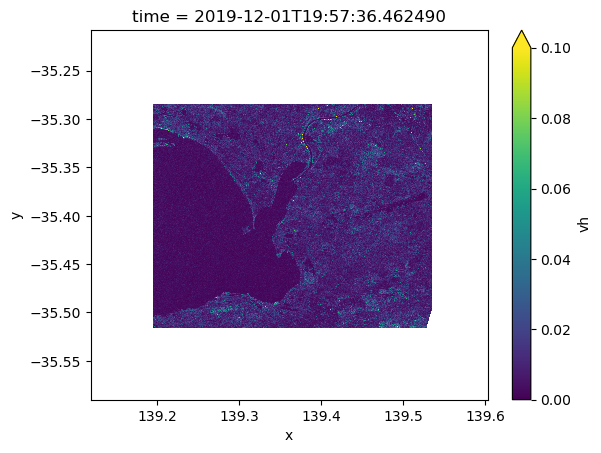

In [10]:
ds.vh[0].plot.imshow(vmin=0, vmax=0.1)

(creating-current-period-datacube_SSM)=
## Creating current period datacube

In [21]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
bbox = [
    139.194,
    -35.516,
    139.535,
    -35.284,
]
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=["2020-01-02", "2020-01-28"],
    ).items()
)
print(f"items found: {len(items)}")
grd_paths_cur = [p.assets["product"].href for p in items]

items found: 2


In [29]:
%%time

# Loop through all reference period observations and build time series
grd_cur_list = []

for grd_path in grd_paths_cur:
    dt_curr = xr.open_datatree(grd_path, engine="zarr", chunks="auto")
    t = np.datetime64(dt_curr.attrs["stac_discovery"]["properties"]["datetime"][:-2], "ns")
    
    group_VH = [x for x in dt_curr.children if "VH" in x][0]  # Changed to dt_curr
    grd = dt_curr[group_VH].measurements.to_dataset().rename({"grd": "vh"})
    
    group_VV = [x for x in dt_curr.children if "VV" in x][0]  # Changed to dt_curr
    grd["vv"] = dt_curr[group_VV].measurements.to_dataset().grd
    grd = grd.assign_coords(time=t)
    
    grd_cur_list.append(grd)

# Concatenate all observations along time dimension
grd_cur = xr.concat(grd_cur_list, dim='time')
grd_cur

CPU times: user 720 ms, sys: 39.5 ms, total: 760 ms
Wall time: 9.54 s


<xarray.Dataset> Size: 14GB
Dimensions:       (time: 2, azimuth_time: 34328, ground_range: 25395)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 275kB 2020-01-06T19:57:22.377...
  * ground_range  (ground_range) float64 203kB 0.0 10.0 ... 2.539e+05 2.539e+05
    line          (time, azimuth_time) float64 549kB nan nan nan ... nan nan nan
    pixel         (time, ground_range) float64 406kB 0.0 1.0 ... 2.539e+04 nan
  * time          (time) datetime64[ns] 16B 2020-01-18T19:57:34.595410 2020-0...
Data variables:
    vh            (time, azimuth_time, ground_range) float32 7GB dask.array<chunksize=(1, 4290, 8192), meta=np.ndarray>
    vv            (time, azimuth_time, ground_range) float32 7GB dask.array<chunksize=(1, 4290, 8192), meta=np.ndarray>

(extract-ground-control-points-for-current-period-spatial-slicing_SSM)=
## Extract Ground Control Points for current period spatial slicing

In [31]:
gcps = dt_curr[group_VH].conditions.gcp.to_dataset()[["latitude", "longitude"]]
gcps

<xarray.Dataset> Size: 4kB
Dimensions:       (azimuth_time: 10, ground_range: 21)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 80B 2020-01-06T19:57:22.37732...
  * ground_range  (ground_range) float64 168B 0.0 1.27e+04 ... 2.539e+05
    line          (azimuth_time) uint32 40B dask.array<chunksize=(10,), meta=np.ndarray>
    pixel         (ground_range) uint32 84B dask.array<chunksize=(21,), meta=np.ndarray>
Data variables:
    latitude      (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>

In [33]:
%%time

mask = (
    (gcps.latitude < bbox[3])
    & (gcps.latitude > bbox[1])
    & (gcps.longitude < bbox[2])
    & (gcps.longitude > bbox[0])
)
idx = np.where(mask == 1)
azimuth_time_slice, ground_range_slice = build_slice(mask.shape, idx)

gcps_crop_cur = gcps.isel(
    dict(azimuth_time=azimuth_time_slice, ground_range=ground_range_slice)
)

azimuth_time_min = gcps_crop_cur.azimuth_time.min().values
azimuth_time_max = gcps_crop_cur.azimuth_time.max().values

ground_range_min = gcps_crop_cur.ground_range.min().values
ground_range_max = gcps_crop_cur.ground_range.max().values

grd_crop_cur = grd_cur.sel(
    dict(
        azimuth_time=slice(azimuth_time_min, azimuth_time_max),
        ground_range=slice(ground_range_min, ground_range_max),
    )
)

gcps_crop_interp = gcps_crop_cur.interp_like(grd_crop_cur)
grd_crop_cur = grd_crop_cur.assign_coords(
    {"latitude": gcps_crop_interp.latitude, "longitude": gcps_crop_interp.longitude}
)
mask_2 = (
    (gcps_crop_interp.latitude < bbox[3])
    & (gcps_crop_interp.latitude > bbox[1])
    & (gcps_crop_interp.longitude < bbox[2])
    & (gcps_crop_interp.longitude > bbox[0])
)
grd_crop_cur = grd_crop_cur.where(mask_2.compute(), drop=True)

grd_crop_cur

CPU times: user 576 ms, sys: 3.59 s, total: 4.16 s
Wall time: 2.69 s


<xarray.Dataset> Size: 383MB
Dimensions:       (time: 2, azimuth_time: 3300, ground_range: 3629)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 26kB 2020-01-06T19:57:26.9809...
  * ground_range  (ground_range) float64 29kB 1.27e+05 1.27e+05 ... 1.633e+05
    line          (azimuth_time) float64 26kB 3.108e+03 3.109e+03 ... 6.407e+03
    pixel         (ground_range) float64 29kB 1.27e+04 1.27e+04 ... 1.633e+04
  * time          (time) datetime64[ns] 16B 2020-01-18T19:57:34.595410 2020-0...
    latitude      (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3629), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3629), meta=np.ndarray>
Data variables:
    vh            (time, azimuth_time, ground_range) float32 96MB dask.array<chunksize=(1, 2701, 1693), meta=np.ndarray>
    vv            (time, azimuth_time, ground_range) float32 96MB dask.array<chunksize=(1, 2701, 1693), meta=np.ndarray>

(calibration-current-period_SSM)=
## Calibration current period

In [36]:
# Select the most recent time step
grd_crop_cur_single = grd_crop_cur.isel(time=-1)  # Get last time step

# Now calibrate this single observation
sigma_lut_cur = dt_curr[group_VH].quality.calibration.sigma_nought

sigma_lut_line_pixel = xr.DataArray(
    data=sigma_lut_cur.data,
    dims=["line", "pixel"],
    coords=dict(
        line=(["line"], sigma_lut_cur.line.values),
        pixel=(["pixel"], sigma_lut_cur.pixel.values),
    ),
)
grd_line_pixel = xr.DataArray(
    data=grd_crop_cur_single.vh.data,  # Use single time step
    dims=["line", "pixel"],
    coords=dict(
        line=(["line"], grd_crop_cur_single.vh.line.values),
        pixel=(["pixel"], grd_crop_cur_single.vh.pixel.values),
    ),
)

sigma_lut_interp_line_pixel = sigma_lut_line_pixel.interp_like(
    grd_line_pixel, method="linear"
)

sigma_lut_interp = xr.DataArray(
    data=sigma_lut_interp_line_pixel.data,
    dims=["azimuth_time", "ground_range"],
    coords=dict(
        azimuth_time=(["azimuth_time"], grd_crop_cur_single.azimuth_time.values),
        ground_range=(["ground_range"], grd_crop_cur_single.ground_range.values),
    ),
)

sigma_0_cur = (abs(grd_crop_cur_single.astype(np.float32)) ** 2) / (sigma_lut_interp**2)
sigma_0_cur

<xarray.Dataset> Size: 288MB
Dimensions:       (azimuth_time: 3300, ground_range: 3629)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 26kB 2020-01-06T19:57:26.9809...
  * ground_range  (ground_range) float64 29kB 1.27e+05 1.27e+05 ... 1.633e+05
    line          (azimuth_time) float64 26kB 3.108e+03 3.109e+03 ... 6.407e+03
    pixel         (ground_range) float64 29kB 1.27e+04 1.27e+04 ... 1.633e+04
    time          datetime64[ns] 8B 2020-01-06T19:57:35.085440
    latitude      (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3629), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3629), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) float32 48MB dask.array<chunksize=(2701, 1693), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 48MB dask.array<chunksize=(2701, 1693), meta=np.ndarray>

(geocoding-current-period_SSM)=
## Geocoding current period

In [37]:
%%time

grid_lat = sigma_0_cur.latitude.values
grid_lon = sigma_0_cur.longitude.values

grid_x_regular, grid_y_regular = create_regular_grid(
    np.nanmin(grid_lon),
    np.nanmax(grid_lon),
    np.nanmin(grid_lat),
    np.nanmax(grid_lat),
    0.0001,  # Resolution in EPSG:4326 lat/lon
)


ds_cur = geocode_grd(sigma_0_cur, grid_x_regular, grid_y_regular)
ds_cur

CPU times: user 3min 47s, sys: 3.34 s, total: 3min 50s
Wall time: 3min 49s


<xarray.Dataset> Size: 297MB
Dimensions:  (time: 1, y: 3825, x: 4848)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-01-06T19:57:35.085440
  * y        (y) float32 15kB -35.59 -35.59 -35.59 ... -35.21 -35.21 -35.21
  * x        (x) float32 19kB 139.1 139.1 139.1 139.1 ... 139.6 139.6 139.6
Data variables:
    vh       (time, y, x) float64 148MB nan nan nan nan nan ... nan nan nan nan
    vv       (time, y, x) float64 148MB nan nan nan nan nan ... nan nan nan nan

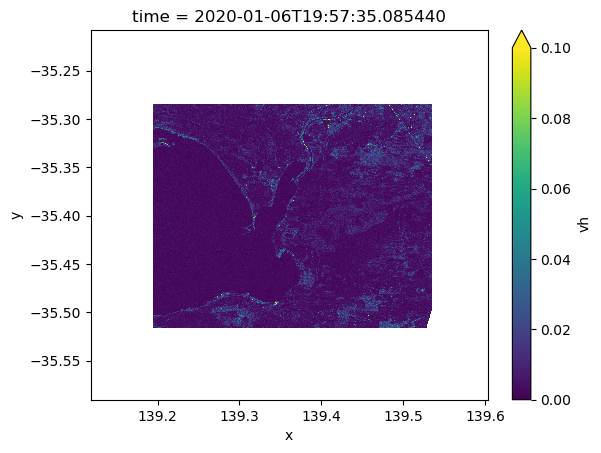

In [38]:
ds_cur.vh[0].plot.imshow(vmin=0, vmax=0.1)

In [19]:
s1_cur

<xarray.Dataset> Size: 287MB
Dimensions:       (azimuth_time: 3300, ground_range: 3624)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 26kB 2020-01-18T19:57:26.4849...
  * ground_range  (ground_range) float64 29kB 1.27e+05 1.27e+05 ... 1.632e+05
    line          (azimuth_time) float64 26kB 3.108e+03 3.109e+03 ... 6.407e+03
    pixel         (ground_range) float64 29kB 1.27e+04 1.27e+04 ... 1.632e+04
    time          datetime64[ns] 8B 2020-01-18T19:57:34.595410
    latitude      (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3624), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 96MB dask.array<chunksize=(3300, 3624), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) float32 48MB dask.array<chunksize=(3300, 2540), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 48MB dask.array<chunksize=(3300, 2540), meta=np.ndarray>

In [39]:
# Get the most recent observation from current period (already single time point)
s1_cur = sigma_0_cur  # This is already your "last" observation

# Calculate dry reference (minimum over time dimension)
dry_ref = sigma_0_ref.min(dim='time')

# Calculate wet reference (maximum over time dimension)  
wet_ref = sigma_0_ref.max(dim='time')

# Calculate Surface Soil Moisture
SSM = (s1_cur - dry_ref) / (wet_ref - dry_ref)

ValueError: Dimension(s) 'time' do not exist. Expected one or more of {'azimuth_time', 'ground_range'}

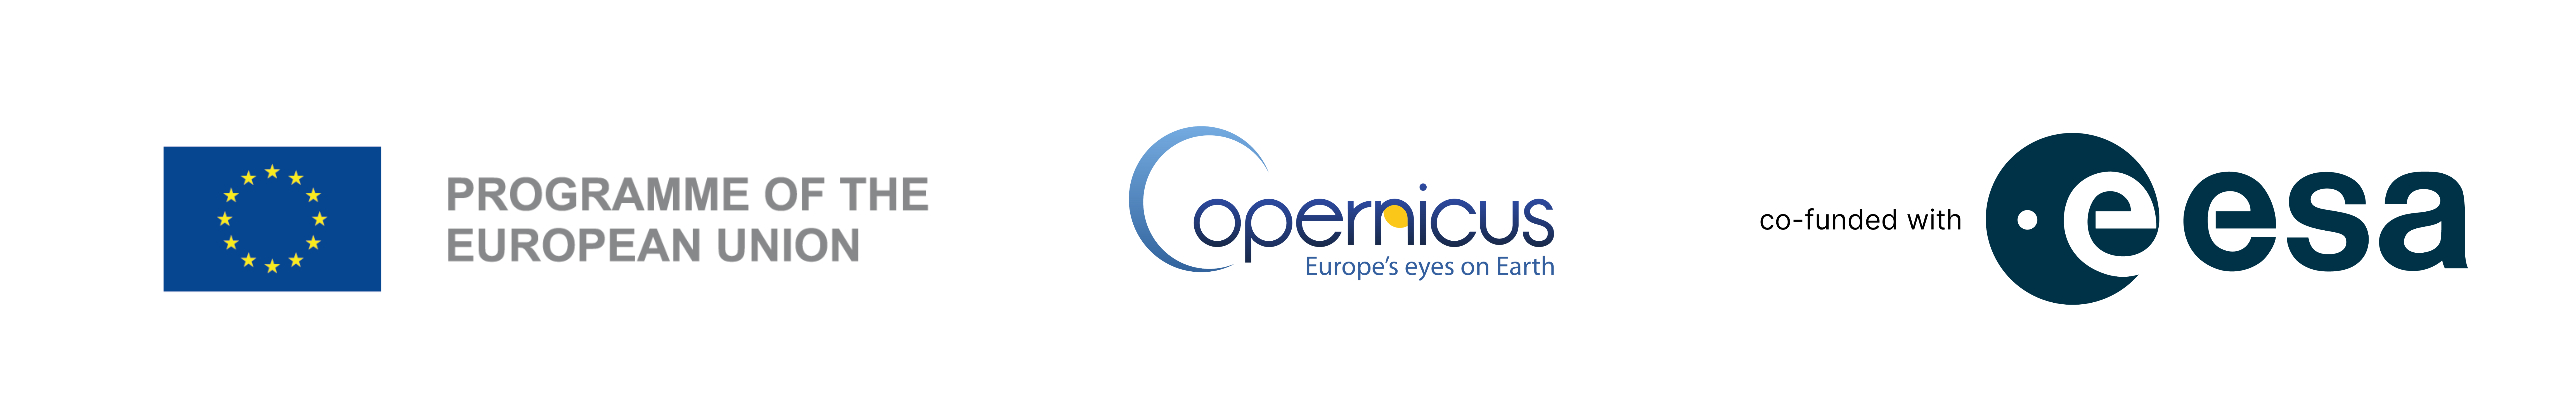